In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re 
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
# from pmdarima import auto_arima
from math import sqrt
import matplotlib.pyplot as plt



# Data Cleaning/Extracting for both Patient side and Physician side



In [2]:

# Physician data for 2024 and 2021

# 2024
df_q11 = pd.read_excel("/Users/nisargpatel/Desktop/University of Niagara Falls/ACADEMICS/Term-2/DAMO-511-16-Data Analytics Case Study-2/Project/Datasets/EMR/2024/Q11.xlsx", header=None)

p1_2024 = float(df_q11.iloc[7, 8]) * 100   # row 'Yes' 
n1_2024 = int(df_q11.iloc[5, 8])    # row 'Unweighted Total' 

print(f"2024 - Physician EMR (ON): p1 = {p1_2024:.3f}, n1 = {n1_2024}")

# 2021
df_q19 = pd.read_excel("/Users/nisargpatel/Desktop/University of Niagara Falls/ACADEMICS/Term-2/DAMO-511-16-Data Analytics Case Study-2/Project/Datasets/EMR/2021/Q19.xlsx", header=None)

p1_2021 = float(df_q19.iloc[10, 16]) * 100  # 'Yes'
n1_2021 = int(df_q19.iloc[9, 16])    # 'Unweighted Total'

print(f"2021 - Physician EMR (ON): p = {p1_2021:.3f}, n = {n1_2021}")



# Patient data for 2024 and 2021

# 2021
df_q16a_2021 = pd.read_excel("/Users/nisargpatel/Desktop/University of Niagara Falls/ACADEMICS/Term-2/DAMO-511-16-Data Analytics Case Study-2/Project/Datasets/Virtual Care/2021/2021_banner_table.xlsx", sheet_name="Q15_Lr1", header=None)

n2_2021 = int(df_q16a_2021.iloc[14, 6])      # Unweighted Total (Ontario)
p2_2021 = float(df_q16a_2021.iloc[18, 6]) * 100   # 'Yes' proportion (Ontario)

print(f"Patient-side digital access (ON, 2021): p2_2021 = {p2_2021:.3f}, n2_2021 = {n2_2021}")


# 2024

df_q15a2 = pd.read_excel("/Users/nisargpatel/Desktop/University of Niagara Falls/ACADEMICS/Term-2/DAMO-511-16-Data Analytics Case Study-2/Project/Datasets/Virtual Care/2024/2024_cdhs_table.xlsx", sheet_name="Q16sum1 Have by Banner1", header=None)

n2 = int(df_q15a2.iloc[5, 5])          # Unweighted Total (Ontario)
p2 = float(df_q15a2.iloc[8, 5]) * 100       # 'Yes' proportion for ON

print(f"Patient-side digital access proxy (ON, 2024): p2 = {p2:.3f}, n2 = {n2}")






2024 - Physician EMR (ON): p1 = 94.220, n1 = 321
2021 - Physician EMR (ON): p = 90.052, n = 667
Patient-side digital access (ON, 2021): p2_2021 = 32.155, n2_2021 = 4844
Patient-side digital access proxy (ON, 2024): p2 = 19.331, n2 = 4690


# TWO-SAMPLE Z-TESTS

In [3]:

def two_prop_z_from_percent(p1_pct, n1, p2_pct, n2):
    p1 = p1_pct / 100.0
    p2 = p2_pct / 100.0
    x1 = p1 * n1
    x2 = p2 * n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (p1 - p2) / se
    return z

# 2024 gap: physicians vs patients 
z_2024 = two_prop_z_from_percent(p1_2024, n1_2024, p2, n2)

# 2021 gap: physicians vs patients
z_2021 = two_prop_z_from_percent(p1_2021, n1_2021, p2_2021, n2_2021)

print("\n--- Z-TEST: Physician EMR vs Patient Digital Access (Ontario) ---")
print(f"2024: Z = {z_2024:.2f}  (diff = {p1_2024 - p2:.1f} percentage points)")
print(f"2021: Z = {z_2021:.2f}  (diff = {p1_2021 - p2_2021:.1f} percentage points)")
print("Rule of thumb: |Z| > 1.96 ⇒ significant at 5% (two-sided).")



--- Z-TEST: Physician EMR vs Patient Digital Access (Ontario) ---
2024: Z = 30.34  (diff = 74.9 percentage points)
2021: Z = 28.72  (diff = 57.9 percentage points)
Rule of thumb: |Z| > 1.96 ⇒ significant at 5% (two-sided).


# Bar Charts

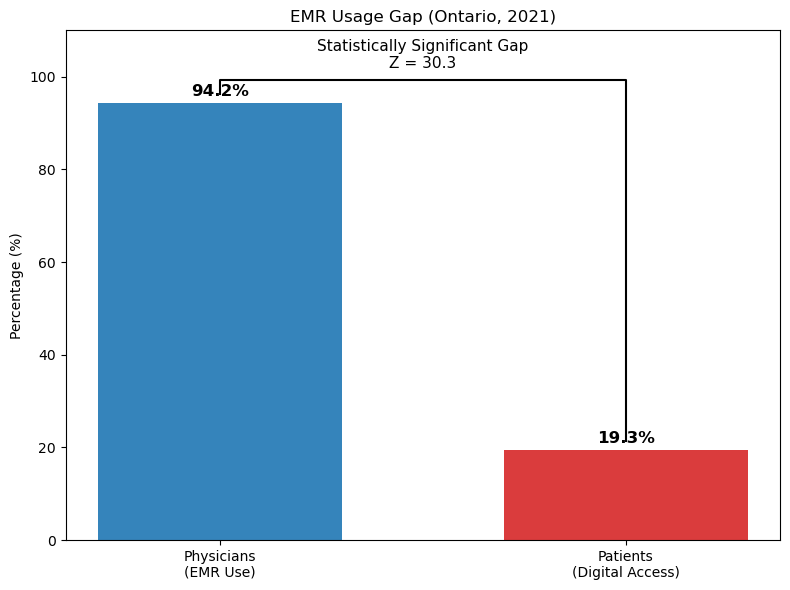

In [4]:
##--- 2024 Plot ---##

p_phys_2024 = p1_2024   
p_pat_2024  = p2        
z_score_2024 = z_2024   

labels = ['Physicians\n(EMR Use)', 'Patients\n(Digital Access)']
values = [p_phys_2024, p_pat_2024]   
colors = ['#1f77b4', '#d62728']      

# bar chart 

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors, width=0.6, alpha=0.9)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

y_line = max(values) + 5

plt.plot(
    [0, 0, 1, 1],
    [values[0] + 2, y_line, y_line, values[1] + 2],
    lw=1.5,
    color='black'
)

plt.text(
    0.5,
    y_line + 2,
    f"Statistically Significant Gap\nZ = {z_score_2024:.1f}",
    ha='center',
    va='bottom',
    fontsize=11
)

plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('EMR Usage Gap (Ontario, 2021)')
plt.tight_layout()
plt.savefig('barrier_a_2024_chart.png', dpi=300)
plt.show()


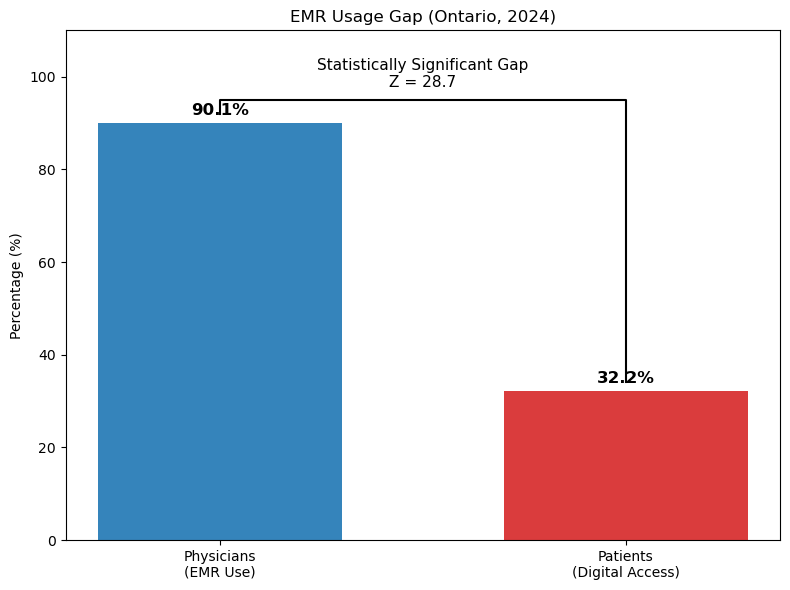

In [5]:
##--- 2021 Plot ---##

p_phys_2021 = p1_2021
p_pat_2021  = p2_2021
z_score_2021 = z_2021


labels = ['Physicians\n(EMR Use)', 'Patients\n(Digital Access)']
values = [p_phys_2021, p_pat_2021]  
colors = ['#1f77b4', '#d62728']     

# bar chart 

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors, width=0.6, alpha=0.9)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

y_line = max(values) + 5

plt.plot(
    [0, 0, 1, 1],
    [values[0] + 2, y_line, y_line, values[1] + 2],
    lw=1.5,
    color='black'
)

plt.text(
    0.5,
    y_line + 2,
    f"Statistically Significant Gap\nZ = {z_score_2021:.1f}",
    ha='center',
    va='bottom',
    fontsize=11
)

plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('EMR Usage Gap (Ontario, 2024)')
plt.tight_layout()
plt.savefig('barrier_a_2024_chart.png', dpi=300)
plt.show()


# Visualisation

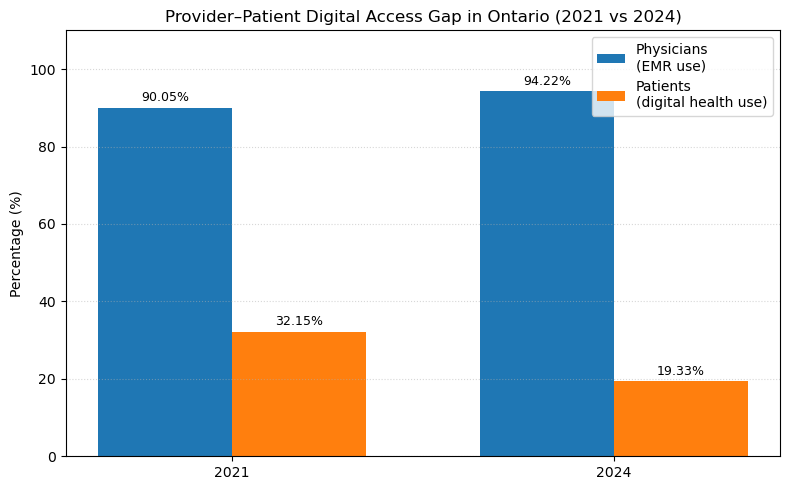

In [6]:
phys_2021 = 90.05   
pat_2021  = 32.15   
phys_2024 = 94.22   
pat_2024  = 19.33   

years = ['2021', '2024']
phys_vals = [phys_2021, phys_2024]
pat_vals  = [pat_2021,  pat_2024]

x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(8, 5))
b1 = plt.bar(x - width/2, phys_vals, width, label='Physicians\n(EMR use)')
b2 = plt.bar(x + width/2, pat_vals,  width, label='Patients\n(digital health use)')

# Add labels on bars
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 1,
                 f"{h:.2f}%", ha='center', va='bottom', fontsize=9)

plt.ylabel("Percentage (%)")
plt.title("Provider–Patient Digital Access Gap in Ontario (2021 vs 2024)")
plt.xticks(x, years)
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
